In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/admin/Documents/0_hw/src')

# Import modules

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import seaborn as sns
import xgboost as xgb
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import KFold

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
from tqdm import tqdm
import re
import pickle
from sklearn.metrics import roc_curve, auc
import re

from tqdm import trange
import pickle
import os
import optuna

from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import threading
import gc

from sklearn.manifold import TSNE
import umap
import dill
from matplotlib.patches import FancyArrowPatch

/home/admin/venvs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [5]:
from utils import PROCESS_STEPS, INPUT_PROFILE, DATA_TYPES
from utils import ColumnClassifier
from utils import squeeze_list

# Load data

In [6]:
data_path = '/home/admin/Documents/0_hw/notebooks/model/260706_feature_store_v3_1_after_cut.parquet'
data = pd.read_parquet(data_path)

In [7]:
[x for x in data.columns if 'Y_NFF' in x]

['Y_NFF_A',
 'Y_NFF_D',
 'Y_NFF_E',
 'Y_NFF_F',
 'Y_NFF_H',
 'Y_NFF_J',
 'Y_NFF_K',
 'Y_NFF_L',
 'Y_NFF_O',
 'Y_NFF_P',
 'Y_NFF_Q',
 'Y_NFF_R',
 'Y_NFF_T',
 'Y_NFF_V',
 'Y_NFF_W',
 'Y_NFF_Z']

# Get column list

In [8]:
column_classifier = ColumnClassifier()
df_cols = column_classifier.transform(data=data)

In [9]:
df_cols

,process_step,data_type,cols,count
0,Mixing,IQC,"[X_IQC_Electrode_Mixing_Cathode_원소_S, X_IQC_El...",31
1,Assembly,IQC,"[X_IQC_Assemble_Assembly_두께_1, X_IQC_Assemble_...",97
2,Mixing,SV,[X_SV_Electrode_Mixing_Anode_Parameter Value_1...,74
3,Coating,SV,[],0
4,Roll Pressing,SV,[X_Anode_SV_Electrode_Roll Pressing_Parameter ...,59
5,Slitting,SV,[X_SV_Electrode_Slitting_Anode_Parameter Value...,48
6,Winding,SV,[X_SV_Assemble_Winding_Parameter Value_음극 노칭 에...,334
7,Assembly,SV,[X_SV_Assemble_Assembly_Parameter Value_상승 시간 ...,304
8,Activation,SV,[],0
9,Mixing,PV,[X_PV_Electrode_Mixing_Anode_D0012010_N_CO_tre...,6933


In [10]:
cols_small_y = (
    df_cols.loc[lambda x :x['data_type'] == 'Small_Y', 'cols']
    .tolist()
)
cols_small_y = squeeze_list(cols_small_y)
cols_small_y = [x for x in cols_small_y if x in data.columns]
cols_small_y[:5]

['y_LQC_Electrode_Coating_Anode_Sliding (-)_Tab Top',
 'y_MES_Electrode_Coating_Cathode_절연 (Top)',
 'y_MES_Electrode_Coating_Cathode_치수_Loading (Top)',
 'y_MES_Electrode_Coating_Anode_외관_표면 (Back)',
 'y_MES_Electrode_Coating_Cathode_외관_표면 (Back)']

In [11]:
cols_sv = (
    df_cols.loc[lambda x :x['data_type'] == 'SV', 'cols']
    .tolist()
)
cols_sv = squeeze_list(cols_sv)
cols_sv[:5]

['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight']

In [12]:
cols_pv = (
    df_cols.loc[lambda x :x['data_type'] == 'PV', 'cols']
    .tolist()
)
cols_pv = squeeze_list(cols_pv)
cols_pv[:5]

['X_PV_Electrode_Mixing_Anode_D0012010_N_CO_trev_1_num',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_MD_hrv_classic_pnn40',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_SB_TransitionMatrix_3ac_sumdiagcov',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_PD_PeriodicityWang_th0_01',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_CO_Embed2_Dist_tau_d_expfit_meandiff']

# Preprocess data

In [13]:
# 1. 중복 컬럼 제거
data = data.loc[:, ~data.columns.duplicated()]

In [14]:
# 2. small y 결측값 fill
for col in tqdm(cols_small_y): 
    data.loc[:, col] = data.loc[:, col].fillna(0)
#data.loc[:, list(set(cols_small_y))] = data.loc[:, list(set(cols_small_y))].fillna(0)

100%|██████████| 87/87 [00:00<00:00, 1828.04it/s]


In [15]:
# 3. datetime 처리
data['07_Before Degas_Finished Date'] = pd.to_datetime(data['07_Before Degas_Finished Date'])
data['week'] = data['07_Before Degas_Finished Date'].dt.isocalendar().week
data['date'] = data['07_Before Degas_Finished Date'].dt.date

In [16]:
# 4. PV 결측값 fill
for col in tqdm(cols_pv) : 
    data.loc[:, col] = data.loc[:, col].fillna(0)
#data.loc[:, list(set(cols_pv))] = data.loc[:, list(set(cols_pv))].fillna(0)

100%|██████████| 18148/18148 [00:10<00:00, 1700.60it/s]


# 전체 IQC 데이터 PCA pickle

In [17]:
cols_iqc = [x for x in data.columns if 'IQC' in x]

In [18]:
data_iqc_mean_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_iqc]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_iqc + ['Y_NFF_A']].mean()
    .fillna(0)
)
display(data_iqc_mean_by_week.head())
display(data_iqc_mean_by_week.tail())

,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_Side_Hole_직경_2,X_IQC_Assemble_Assembly_브릿지_폭_4,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.898000,2.063077,7.992308,0.123077,2.015385,0.000000,0.497692,2.886000,10.224000,0.941176
6,0.456611,45.305858,0.031874,40.702140,0.575936,0.228668,13.498436,0.253169,2.979756,5.006958,...,0.899705,2.078197,8.283819,0.130031,2.221263,722.599078,0.499207,2.875555,10.253416,0.934783
7,0.468358,45.304336,0.031828,40.766218,0.588273,0.229965,13.498511,0.255456,2.979597,5.007024,...,0.902865,2.122160,9.133667,0.150376,2.822764,722.802093,0.503533,2.856200,10.307926,0.976824
8,0.653631,45.316768,0.028754,41.754280,0.766294,0.250650,13.499811,0.288372,2.977306,5.008435,...,0.906003,2.180401,10.268145,0.177258,3.618966,721.706678,0.508557,2.835160,10.360261,1.000000
9,0.697008,45.319667,0.025339,42.017188,0.805514,0.255648,13.501970,0.290560,2.973795,5.010505,...,0.907242,2.174024,10.232402,0.168909,3.439779,703.505464,0.496302,2.795347,10.349884,0.969647


,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_Side_Hole_직경_2,X_IQC_Assemble_Assembly_브릿지_폭_4,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
20,0.841895,45.319334,0.024540,42.591549,0.837323,0.272341,13.501487,0.316548,2.971600,5.011200,...,0.910000,2.230588,11.282353,0.217059,4.123529,704.166667,0.537059,2.7100,10.330000,1.000000
21,0.631139,45.316068,0.026054,41.573610,0.717903,0.248319,13.499112,0.281307,2.972246,5.010329,...,0.906000,2.321937,13.028571,0.254214,5.488095,710.937500,0.550238,2.8370,10.362000,1.000000
23,0.841895,45.319334,0.024540,42.591549,0.837323,0.272341,13.501487,0.316548,2.971600,5.011200,...,0.906000,2.070000,7.933333,0.130000,1.900000,0.000000,0.490000,2.8370,10.362000,0.000000
24,0.625800,45.287657,0.026371,41.656203,0.755875,0.245235,13.506829,0.275017,2.969431,5.013020,...,0.898300,2.134462,9.367179,0.151573,2.985641,710.000000,0.496154,2.8596,10.257400,0.739130
25,0.841895,45.319334,0.024540,42.591549,0.837323,0.272341,13.501487,0.316548,2.971600,5.011200,...,0.899143,2.107088,8.849464,0.145307,2.597914,713.583333,0.504545,2.8790,10.243714,0.666667


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_iqc_mean_by_week)


if not os.path.exists('pca_iqc.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca_iqc.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca_iqc.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


/home/admin/venvs/py312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [20]:
data_iqc_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_iqc_mean_by_week, "index", None)
)
data_iqc_pca['Y_NFF_A'] = data_iqc_mean_by_week['Y_NFF_A']

In [21]:
x = data_iqc_pca['PC1'].values
y = data_iqc_pca['PC2'].values
score = (1-data_iqc_pca['Y_NFF_A'].values)
week = data_iqc_pca.index.tolist()

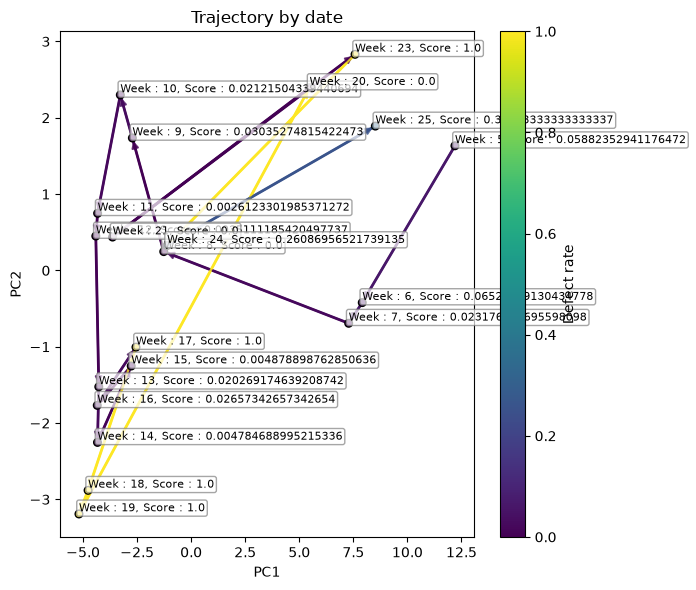

In [22]:
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_iqc_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

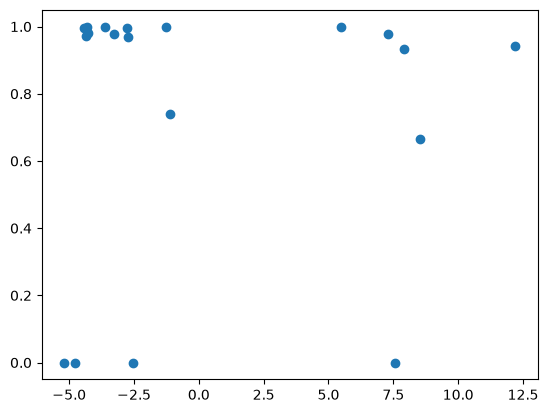

In [23]:
plt.scatter(
    data_iqc_pca['PC1'],
    data_iqc_pca['Y_NFF_A']
)

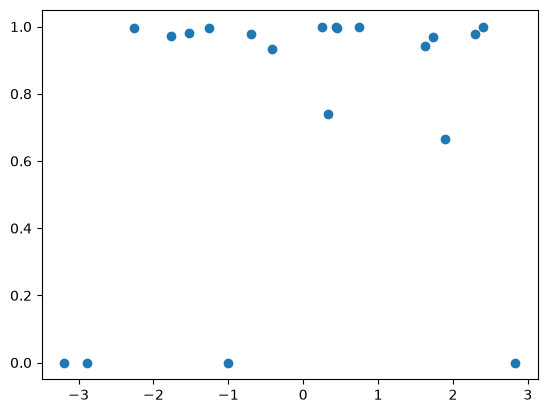

In [24]:
plt.scatter(
    data_iqc_pca['PC2'],
    data_iqc_pca['Y_NFF_A']
)

In [25]:
data_iqc_pca

,PC1,PC2,Y_NFF_A
week,,,
5,12.197606,1.632935,0.941176
6,7.911565,-0.421844,0.934783
7,7.284201,-0.692690,0.976824
8,-1.267170,0.246380,1.000000
9,-2.717814,1.734982,0.969647
10,-3.275162,2.299193,0.978785
11,-4.324920,0.748116,0.997388
12,-4.408926,0.450162,0.996489
13,-4.270928,-1.524657,0.979731


# 전체 SV 데이터 PCA pickle

In [26]:
data_sv_count_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + ['Y_NFF_A']].count()
    .fillna(0)
)
display(data_sv_count_by_week.head())
display(data_sv_count_by_week.tail())

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
5,34,14,34,34,34,34,14,34,34,14,...,0,0,34,34,34,34,34,34,34,34
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,197,197,1196,1196,1196,1196,1196,1196,1196,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,3084,3084,6429,6429,6429,6429,6429,6429,6429,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,5176,5176,6316,6316,6316,6316,6316,6316,6316,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,7314,7314,7314,7314,7314,7314,7314,7314,7314,7314


,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
20,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
21,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
23,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
24,23,17,23,23,23,23,17,23,23,17,...,5,5,23,23,23,23,23,23,23,23
25,8,9,8,8,8,8,9,8,8,9,...,1,1,9,9,9,9,9,9,9,9


In [27]:
(
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=100]
)

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,197,197,1196,1196,1196,1196,1196,1196,1196,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,3084,3084,6429,6429,6429,6429,6429,6429,6429,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,5176,5176,6316,6316,6316,6316,6316,6316,6316,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,7314,7314,7314,7314,7314,7314,7314,7314,7314,7314
10,3028,2536,3028,3028,3028,3028,2536,3028,3028,2536,...,3099,3099,3111,3111,3111,3111,3111,3111,3111,3111
11,3347,3356,3347,3347,3347,3347,3356,3347,3347,3356,...,3760,3760,3828,3828,3828,3828,3828,3828,3828,3828
12,5656,5572,5656,5656,5656,5656,5572,5656,5656,5572,...,5825,5825,5981,5981,5981,5981,5981,5981,5981,5981
13,4910,6079,4910,4910,4910,4910,6079,4910,4910,6079,...,6167,6167,6167,6167,6167,6167,6167,6167,6167,6167
14,3477,3519,3477,3477,3477,3477,3519,3477,3477,3519,...,3553,3553,3553,3553,3553,3553,3553,3553,3553,3553


In [28]:
target_weeks = (
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=50]
).index

In [29]:
data_sv_mean_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + ['Y_NFF_A']].mean()
    .loc[target_weeks]
    .fillna(0)
)
data_sv_mean_by_week.head()

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.978785


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week.drop('Y_NFF_A', axis=1))


if not os.path.exists('pca.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [31]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca['Y_NFF_A'] = data_sv_mean_by_week['Y_NFF_A']

In [32]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca['Y_NFF_A'].values)
week = data_sv_pca.index.tolist()

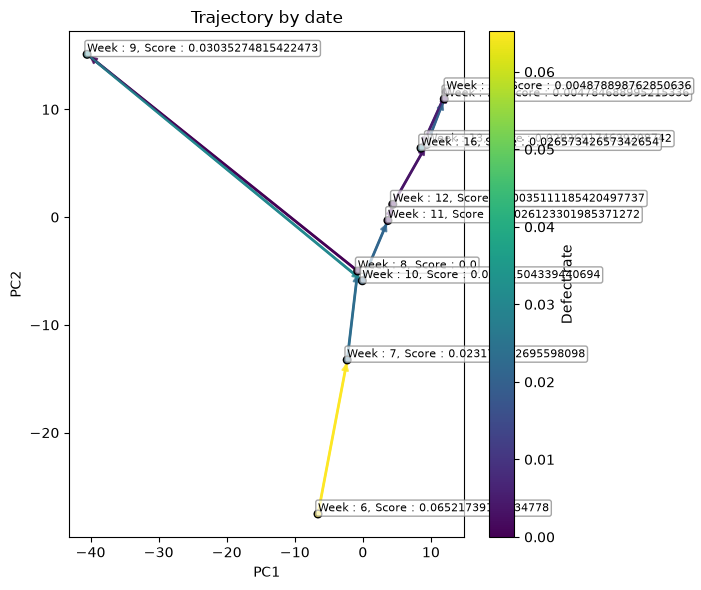

In [33]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

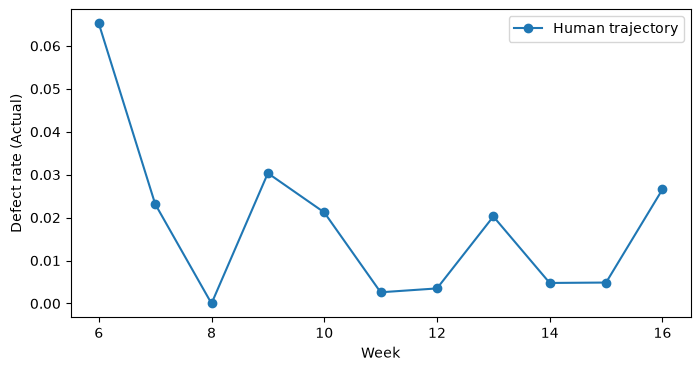

In [34]:
plt.figure(figsize=(8, 4))

plt.plot(
    data_sv_mean_by_week.index.tolist(),
    (1-data_sv_mean_by_week['Y_NFF_A']).tolist(),
    marker='o',
    label='Human trajectory'
)
plt.xlabel('Week')
plt.ylabel('Defect rate (Actual)')
plt.legend()

plt.show()

In [35]:
data_sv_pca

,PC1,PC2,Y_NFF_A
week,,,
6,-6.589147,-27.547535,0.934783
7,-2.301782,-13.255460,0.976824
8,-0.757794,-5.003513,1.000000
9,-40.502193,15.108627,0.969647
10,-0.072633,-5.907004,0.978785
11,3.680634,-0.313389,0.997388
12,4.394294,1.187104,0.996489
13,9.385357,6.739692,0.979731
14,11.956199,10.963002,0.995215


# SV+IQC 데이터 PCA

In [36]:
data_sv_count_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv + cols_iqc]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + cols_iqc + ['Y_NFF_A']].count()
    .fillna(0)
)
display(data_sv_count_by_week.head())
display(data_sv_count_by_week.tail())

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
5,34,14,34,34,34,34,14,34,34,14,...,32,14,14,14,14,0,14,32,32,34
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,1079,468,468,468,468,31,468,1079,1079,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,6005,1214,1214,1214,1214,314,1214,6005,6005,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,6250,2258,2258,2258,2258,1183,2258,6250,6250,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,6956,2655,2655,2655,2655,1769,2655,6956,6956,7314


,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
20,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
21,9,9,9,9,9,9,9,9,9,9,...,5,9,9,9,9,8,9,5,5,9
23,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,1
24,23,17,23,23,23,23,17,23,23,17,...,20,15,15,15,15,3,15,20,20,23
25,8,9,8,8,8,8,9,8,8,9,...,7,9,9,9,9,2,9,7,7,9


In [37]:
(
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=100]
)

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,1079,468,468,468,468,31,468,1079,1079,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,6005,1214,1214,1214,1214,314,1214,6005,6005,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,6250,2258,2258,2258,2258,1183,2258,6250,6250,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,6956,2655,2655,2655,2655,1769,2655,6956,6956,7314
10,3028,2536,3028,3028,3028,3028,2536,3028,3028,2536,...,2982,2536,2536,2536,2536,1776,2536,2982,2982,3111
11,3347,3356,3347,3347,3347,3347,3356,3347,3347,3356,...,2072,3356,3356,3356,3356,3022,3356,2072,2072,3828
12,5656,5572,5656,5656,5656,5656,5572,5656,5656,5572,...,397,5536,5536,5536,5536,4946,5536,397,397,5981
13,4910,6079,4910,4910,4910,4910,6079,4910,4910,6079,...,1013,5030,5030,5030,5030,4842,5030,1013,1013,6167
14,3477,3519,3477,3477,3477,3477,3519,3477,3477,3519,...,2374,1371,1371,1371,1371,928,1371,2374,2374,3553


In [38]:
target_weeks = (
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=50]
).index

In [39]:
data_sv_mean_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv + cols_iqc]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + cols_iqc + ['Y_NFF_A']].mean()
    .loc[target_weeks]
    .fillna(0)
)
data_sv_mean_by_week.head()

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.899705,2.078197,8.283819,0.130031,2.221263,722.599078,0.499207,2.875555,10.253416,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.902865,2.122160,9.133667,0.150376,2.822764,722.802093,0.503533,2.856200,10.307926,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.906003,2.180401,10.268145,0.177258,3.618966,721.706678,0.508557,2.835160,10.360261,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.907242,2.174024,10.232402,0.168909,3.439779,703.505464,0.496302,2.795347,10.349884,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.907266,2.175282,10.266279,0.172511,3.416866,700.045420,0.500453,2.781617,10.336903,0.978785


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week.drop('Y_NFF_A', axis=1))


if not os.path.exists('pca_sv_iqc.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca_sv_iqc.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca_sv_iqc.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [41]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca['Y_NFF_A'] = data_sv_mean_by_week['Y_NFF_A']

In [42]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca['Y_NFF_A'].values)
week = data_sv_pca.index.tolist()

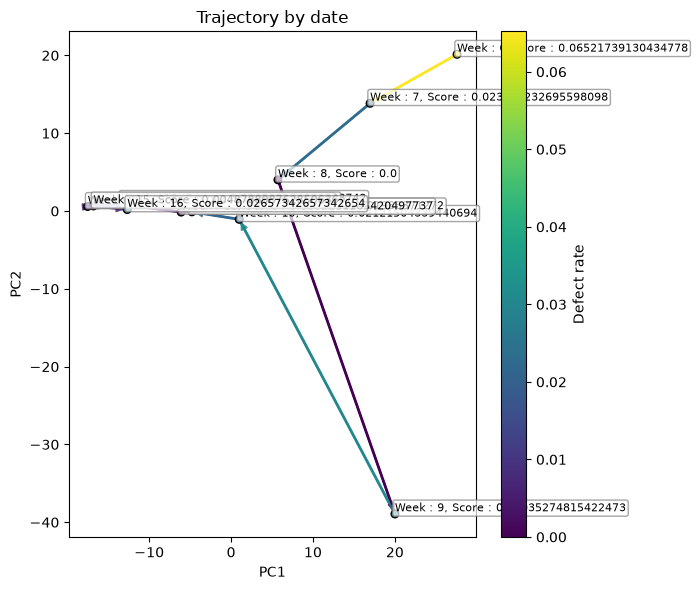

In [43]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

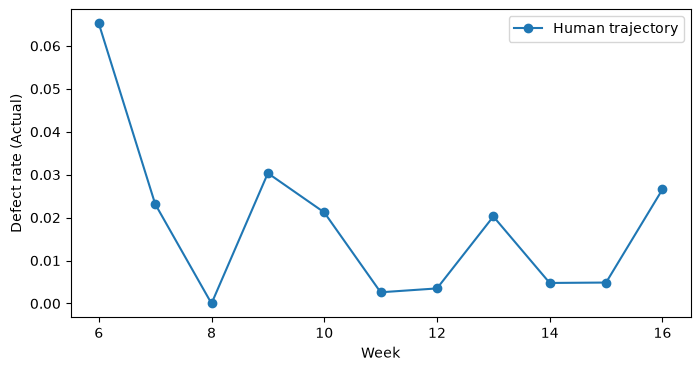

In [44]:
plt.figure(figsize=(8, 4))

plt.plot(
    data_sv_mean_by_week.index.tolist(),
    (1-data_sv_mean_by_week['Y_NFF_A']).tolist(),
    marker='o',
    label='Human trajectory'
)
plt.xlabel('Week')
plt.ylabel('Defect rate (Actual)')
plt.legend()

plt.show()

In [45]:
data_sv_pca

,PC1,PC2,Y_NFF_A
week,,,
6,27.595817,20.135548,0.934783
7,16.973727,13.840710,0.976824
8,5.722949,4.006160,1.000000
9,20.007022,-38.933765,0.969647
10,0.991055,-1.070915,0.978785
11,-4.788548,-0.106467,0.997388
12,-6.098615,-0.139816,0.996489
13,-13.401588,0.849783,0.979731
14,-17.514829,0.582470,0.995215


# 백테스트

In [46]:
data_sv_mean_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.899705,2.078197,8.283819,0.130031,2.221263,722.599078,0.499207,2.875555,10.253416,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.902865,2.122160,9.133667,0.150376,2.822764,722.802093,0.503533,2.856200,10.307926,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.906003,2.180401,10.268145,0.177258,3.618966,721.706678,0.508557,2.835160,10.360261,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.907242,2.174024,10.232402,0.168909,3.439779,703.505464,0.496302,2.795347,10.349884,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.907266,2.175282,10.266279,0.172511,3.416866,700.045420,0.500453,2.781617,10.336903,0.978785
11,474.714096,497.149338,539.318046,9.807290,138.560414,126.027460,1336.835146,255.580493,30.739655,77.719184,...,0.905851,2.358174,13.771174,0.282563,5.997617,704.133879,0.576105,2.826582,10.348273,0.997388
12,474.613030,497.400101,572.458451,9.980552,135.752095,134.704579,1337.500000,255.530428,30.721738,77.700226,...,0.905282,2.369294,13.914720,0.280209,6.116711,705.245269,0.563446,2.813448,10.353070,0.996489
13,474.792994,497.370301,570.081466,9.957230,136.837169,131.518167,1337.420834,255.625703,30.737617,77.702617,...,0.901799,2.373020,13.908244,0.244707,6.156573,707.625981,0.487755,2.753780,10.411270,0.979731
14,475.450618,497.400000,574.669255,9.994248,140.802258,119.874346,1337.500000,255.973857,30.795643,77.700000,...,0.900008,2.345068,13.541375,0.240063,5.868851,733.321121,0.493426,2.710362,10.446336,0.995215


In [47]:
from model_v2 import CascadeModel
import gc
from utils import clean_col_name

In [48]:
model_name = 'N32S'
n_trials = 10
lb_margin = 0.05
ub_margin = 0.05
threshold_constraint = 4

model_version = 'v2'

In [49]:
data_sv_mean_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_IQC_Electrode_Mixing_Anode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_밀도_Tap,X_IQC_Electrode_Mixing_Cathode_입도_D95,X_IQC_Electrode_Mixing_Cathode_Excess_Li_LiOH,X_IQC_Electrode_Mixing_Cathode_입도_D5,X_IQC_Electrode_Mixing_Cathode_원소_B,X_IQC_Electrode_Mixing_Cathode_Excess_Li_Total,X_IQC_Electrode_Mixing_Anode_입도_D10,X_IQC_Electrode_Mixing_Anode_입도_D90,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.899705,2.078197,8.283819,0.130031,2.221263,722.599078,0.499207,2.875555,10.253416,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.902865,2.122160,9.133667,0.150376,2.822764,722.802093,0.503533,2.856200,10.307926,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.906003,2.180401,10.268145,0.177258,3.618966,721.706678,0.508557,2.835160,10.360261,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.907242,2.174024,10.232402,0.168909,3.439779,703.505464,0.496302,2.795347,10.349884,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.907266,2.175282,10.266279,0.172511,3.416866,700.045420,0.500453,2.781617,10.336903,0.978785
11,474.714096,497.149338,539.318046,9.807290,138.560414,126.027460,1336.835146,255.580493,30.739655,77.719184,...,0.905851,2.358174,13.771174,0.282563,5.997617,704.133879,0.576105,2.826582,10.348273,0.997388
12,474.613030,497.400101,572.458451,9.980552,135.752095,134.704579,1337.500000,255.530428,30.721738,77.700226,...,0.905282,2.369294,13.914720,0.280209,6.116711,705.245269,0.563446,2.813448,10.353070,0.996489
13,474.792994,497.370301,570.081466,9.957230,136.837169,131.518167,1337.420834,255.625703,30.737617,77.702617,...,0.901799,2.373020,13.908244,0.244707,6.156573,707.625981,0.487755,2.753780,10.411270,0.979731
14,475.450618,497.400000,574.669255,9.994248,140.802258,119.874346,1337.500000,255.973857,30.795643,77.700000,...,0.900008,2.345068,13.541375,0.240063,5.868851,733.321121,0.493426,2.710362,10.446336,0.995215


In [50]:
for week in data_sv_count_by_week.index : 
    filename_result = f"result_{model_version}_{model_name}_maximize_n_trials_{n_trials}_week_{week}.csv"
    if not os.path.exists(filename_result) : 
        gc.collect()
        # 1. 데이터 Split
        data_limited_by_week = data.loc[lambda x : x['week']<=week]

        x_train, x_test, y_train, y_test = train_test_split(
            data_limited_by_week,
            data_limited_by_week
            #data.loc[lambda x : x['week']<=week]
            , test_size=0.2, random_state=42)

        del data_limited_by_week
        gc.collect()

        # 2-1. 모델 불러오기
        filename_model = f"model_{model_version}_{model_name}_week_{week}.dill"
        if os.path.exists(filename_model) :
            with open(filename_model, 'rb') as f : 
                model = dill.load(f)
        
        #if True : 
        else : # 2-2. 없으면 모델 학습
            model = CascadeModel(
                df_cols=df_cols)

            model.fit(x_train, y_train)
            
            with open(f'model_week_{week}.dill', 'wb') as f : 
                dill.dump(model, f)
        
        # 2-3. 예측값 생성
        pred = model.predict(x_test)

        # 3. 초기값 설정
        x0 = (
            x_train
            .iloc[-1]
        )

        # 4. 상/하한 설정
        bounds = {
            col : (data_sv_mean_by_week[col].min() - abs(data_sv_mean_by_week[col].min() )*lb_margin, 
            data_sv_mean_by_week[col].max() + abs(data_sv_mean_by_week[col].max())*ub_margin)
            for col in data_sv_count_by_week.columns
        }
        
        # 5. Constraint로 넣을 컬럼 설정
        ## 변동성 없는 컬럼 그대로 사용, IQC 그대로 사용    
        cols_low_deviation = (
            (
            data_sv_mean_by_week.nunique()
            [data_sv_mean_by_week.nunique()<=threshold_constraint]
            .index.tolist()
            )
        )

        cols_iqc = [x for x in data.columns if 'IQC' in x]

        cols_to_fix = cols_low_deviation + cols_iqc

        # 6. 목적함수 정의
        def objective(trial):
            gc.collect()
            print(f"Running trial {trial.number} in {threading.current_thread()}")
            # 6-1. 초기값 설정
            x_new = x0.copy()

            # 6-2. Constraint 제외하고 변경할 값 제안
            opt_cols = list(set(cols_sv) - set(cols_to_fix))

            for col in opt_cols : 
                low, high = bounds[col]
                x_new[col] = trial.suggest_float(col, low, high)

            X = pd.DataFrame([x_new])

            # 전체 유형 불량에 대한 평균값 사용 (가중치 동일)
            p_bad = model.predict(X).mean()
            return p_bad

        # 7. 최적화
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, 
        n_trials=n_trials, 
        show_progress_bar=False, 
        #n_jobs=1
        )

        # 8. 결과 저장
        pd.DataFrame([study.best_params]).to_csv(filename_result)

/home/admin/venvs/py312/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [16:14:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Running trial 0 in <_MainThread(MainThread, started 139863899898496)>
Running trial 1 in <_MainThread(MainThread, started 139863899898496)>
Running trial 2 in <_MainThread(MainThread, started 139863899898496)>
Running trial 3 in <_MainThread(MainThread, started 139863899898496)>
Running trial 4 in <_MainThread(MainThread, started 139863899898496)>
Running trial 5 in <_MainThread(MainThread, started 139863899898496)>
Running trial 6 in <_MainThread(MainThread, started 139863899898496)>
Running trial 7 in <_MainThread(MainThread, started 139863899898496)>
Running trial 8 in <_MainThread(MainThread, started 139863899898496)>
Running trial 9 in <_MainThread(MainThread, started 139863899898496)>


: 

: 

In [ ]:
filelist = [x for x in 
os.listdir()
if f"result_{model_version}_{model_name}_maximize_n_trials_{n_trials}" in x]
filelist.sort()

data_sv_result = []

for filename in filelist :
    tmp = pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_6.csv").drop('Unnamed: 0', axis=1)
    data_sv_result.append(tmp)

data_sv_result = pd.concat(data_sv_result)
data_sv_result.index = data_sv_mean_by_week_with_param.index + 100

data_sv_result

In [ ]:
data_sv_result = pd.concat([
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_6.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_7.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_8.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_9.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_10.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_11.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_12.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_13.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_14.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_15.csv").drop('Unnamed: 0', axis=1),
], axis=0)
data_sv_result.index = [
    106,
    107,
    108,
    109,
    110,
    111,
    112,
    113,
    114,
    115
]
data_sv_result 

In [ ]:
data_sv_mean_by_week_with_param = pd.concat([data_sv_mean_by_week, data_sv_result], axis=0)
data_sv_mean_by_week_with_param = data_sv_mean_by_week_with_param
for col in data_sv_mean_by_week_with_param.drop('Y_NFF_A', axis=1).columns : 
    data_sv_mean_by_week_with_param[col] = data_sv_mean_by_week_with_param[col].ffill()
data_sv_mean_by_week_with_param

In [ ]:
data_sv_mean_by_week = data_sv_mean_by_week_with_param

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week.drop('Y_NFF_A', axis=1))


if not os.path.exists('pca.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [ ]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca['Y_NFF_A'] = data_sv_mean_by_week['Y_NFF_A']

In [ ]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca['Y_NFF_A'].values)
week = data_sv_pca.index.tolist()

In [ ]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

In [ ]:
data_sv_pca